# ML Challenge 2026: Competition-Grade Business Entity Resolution Solution
---
**Objective**: Build a competition-winning entity resolution pipeline that matches reference business records from **Source 1** with candidate duplicates in **Source 2** and **Source 3**.

**Evaluation Metric**: Official **Macro $F_{0.5}$** across all test Source 1 entities (Precision is weighted $2\times$ over Recall, with strict singleton evaluation).

### High-Level Architectural Flow:
1. **Multi-Representation Normalization**: Unicode NFKC, transliteration (Unidecode), legal suffix detachment, address token parsing & postal code extraction.
2. **Multi-Channel Adaptive Blocking**: Inverted indexes with country, postal code, core name, rare token, and transliterated keys. Dynamic sub-blocking prevents combinatorial explosion without sacrificing recall.
3. **Statistical Token Weighting**: Offline reference corpus IDF computation to down-weight ubiquitous tokens (e.g., *mart*, *traders*, *store*) and elevate distinct proper nouns.
4. **Rich Pairwise Feature Engineering**: Exact identifiers, token Jaccard, RapidFuzz string similarities (Levenshtein, Jaro-Winkler, token sort/set), length diffs, and channel metadata.
5. **Entity-Aware Validation Split**: S1 entity partitioning preventing target leak.
6. **Cost-Sensitive GBDT Matching**: LightGBM pairwise ranking/classification tuned specifically to maximize $F_{0.5}$ macro score.
7. **Post-Processing & Leaderboard Validation**: Confidence margin thresholding, singleton guardrails, and compliance checks with `validate_submission.py`.


# Phase 0 — Configuration & Environment Setup
Initializes all core imports, random seeds, project directory paths, dataset pointers, artifact storage, and operational control switches (`RUN_EXPENSIVE`, `SAMPLE_ROWS`, `CHUNK_SIZE`).


In [1]:
import os
import sys
import gc
import re
import math
import time
import random
import unicodedata
import collections
from pathlib import Path
from typing import Dict, List, Set, Tuple, Optional, Any, Iterator

# Core Data Science & High Performance Libraries
import numpy as np
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq

# Similarity & Text Normalization
import rapidfuzz
from rapidfuzz import fuzz, distance
from rapidfuzz.distance import Levenshtein as lev, JaroWinkler as jw
from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

# GBDT Frameworks
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Utilities & Visualization
from tqdm.auto import tqdm
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure local project source code is in Python path
PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import reusable modules created in src/
from src.normalization import normalize_text, normalize_address
from src.blocking import extract_blocking_keys, AdaptiveBlocker
from src.features import extract_pairwise_features, jaccard_similarity
from src.metrics import compute_f_beta_entity, evaluate_macro_f_beta
from src.pipeline import stream_tsv_chunks, export_submission, compute_corpus_token_idf
from src.inference import run_test_inference, save_model_bundle, load_model_bundle

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("Environment successfully initialized.")
print(f"Project Root: {PROJECT_ROOT}")


Environment successfully initialized.
Project Root: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge


In [2]:
# Global Configuration Variables & Control Flags
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Control execution footprint during notebook exploration
RUN_EXPENSIVE = False         # Toggle to True when you want to run expensive full-dataset operations
SAMPLE_ROWS = 10_000          # Row limit for interactive fast audits and prototyping
CHUNK_SIZE = 100_000          # Batch size for streaming large TSV files
MAX_CANDIDATES = 100          # Maximum candidates per entity from blocking

# Environment-aware dataset directory discovery (supports local Windows, Linux, and Google Colab)
colab_candidate = Path("/content/drive/MyDrive/ML_challenge/student_resource/dataset")
local_candidate = PROJECT_ROOT / "student_resource" / "dataset"

if colab_candidate.exists():
    DATA_DIR = colab_candidate
elif local_candidate.exists():
    DATA_DIR = local_candidate
else:
    # Fallback to local candidate as default
    DATA_DIR = local_candidate

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
OUTPUT_DIR = PROJECT_ROOT / "output"

for d in [ARTIFACT_DIR, MODEL_DIR, CHECKPOINT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directories verified:")
print(f" - Data Dir:  {DATA_DIR} (Exists: {DATA_DIR.exists()})")
print(f" - Train Dir: {TRAIN_DIR} (Exists: {TRAIN_DIR.exists()})")
print(f" - Test Dir:  {TEST_DIR} (Exists: {TEST_DIR.exists()})")
print(f" - Artifacts: {ARTIFACT_DIR}")
print(f" - Outputs:   {OUTPUT_DIR}")
print(f"Control Flags: RUN_EXPENSIVE={RUN_EXPENSIVE}, SAMPLE_ROWS={SAMPLE_ROWS}")


Directories verified:
 - Data Dir:  C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\student_resource\dataset (Exists: True)
 - Train Dir: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\student_resource\dataset\train (Exists: True)
 - Test Dir:  C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\student_resource\dataset\test (Exists: True)
 - Artifacts: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts
 - Outputs:   C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\output
Control Flags: RUN_EXPENSIVE=False, SAMPLE_ROWS=10000


# Phase 1 — Data Discovery
Scans the dataset directory, prints file sizes, and safely reads a small preview sample from each file without loading entire multi-gigabyte files into RAM.


In [3]:
# 1. Discover all files, extensions, and disk sizes in dataset directories
def scan_dataset_directory(base_dir: Path) -> pd.DataFrame:
    records = []
    for f in sorted(base_dir.rglob("*.tsv")):
        size_mb = f.stat().st_size / (1024 * 1024)
        records.append({
            "File Name": f.name,
            "Folder": f.parent.name,
            "Path": str(f.relative_to(PROJECT_ROOT)),
            "Size (MB)": round(size_mb, 2)
        })
    return pd.DataFrame(records)

df_files = scan_dataset_directory(DATA_DIR)
print(f"Discovered {len(df_files)} TSV files:")
display(df_files)


Discovered 7 TSV files:


,File Name,Folder,Path,Size (MB)
0,test_source1.tsv,test,student_resource\dataset\test\test_source1.tsv,166.91
1,test_source2.tsv,test,student_resource\dataset\test\test_source2.tsv,485.86
2,test_source3.tsv,test,student_resource\dataset\test\test_source3.tsv,482.56
3,train_ground_truth.tsv,train,student_resource\dataset\train\train_ground_tr...,121.13
4,train_source1.tsv,train,student_resource\dataset\train\train_source1.tsv,200.34
5,train_source2.tsv,train,student_resource\dataset\train\train_source2.tsv,466.63
6,train_source3.tsv,train,student_resource\dataset\train\train_source3.tsv,480.37


In [4]:
# 2. Inspect headers and read a small 5-row preview sample from each TSV
print("=" * 80)
print("PREVIEWING SCHEMA AND FIRST 5 ROWS PER FILE (SAFE READ)")
print("=" * 80)

for idx, row in df_files.iterrows():
    path = PROJECT_ROOT / row['Path']
    sample_df = pl.read_csv(str(path), separator="\t", n_rows=5, ignore_errors=True)
    print(f"\nFile: {row['File Name']} | Shape Preview: {sample_df.shape}")
    print(f"Columns: {sample_df.columns}")
    display(sample_df.to_pandas())


PREVIEWING SCHEMA AND FIRST 5 ROWS PER FILE (SAFE READ)

File: test_source1.tsv | Shape Preview: (5, 4)
Columns: ['entity_id', 'business_name', 'business_address', 'country']


,entity_id,business_name,business_address,country
0,S1-714132312,Zephay Labs Inc,"2621 Cotten Road, Tyler, TX",US
1,S1-106407869,Vision Partners Corp,"IA, Iowa City, 1064 Newton Rd, Unit 11",US
2,S1-156285671,<< Team Ecole,"175 Boulevard du Président Franklin Roosevelt,...",France
3,S1-689823050,Red Perfect Trading,"Mirzapur, Ews 12, Uttar Pradesh, Mirzapursadar...",India
4,S1-921369899,ZNB Club SARL,"Nouvelle-Aquitaine, La Teste-de-Buch, 5 bis Ru...",France



File: test_source2.tsv | Shape Preview: (5, 4)
Columns: ['entity_id', 'business_name', 'business_address', 'country']


,entity_id,business_name,business_address,country
0,S2-192345572,Brahma Infosoft,"COIMATORE COLONY, HUNSUR TQMYSORE DIST., Karna...",India
1,S2-566025912,Marina Ecole France Sarl,"63 R. DE DIEPPE, LILLE, Hauts-de-France",France
2,S2-158121477,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",France
3,S2-89663826,Apex Summit,"67 KENTUCKY ST, SALYERSVILLE, KY",US
4,S2-884102769,Fresh Truist,"8264 FILLY COURT, ROANOKE COUNTY, VA",US



File: test_source3.tsv | Shape Preview: (5, 4)
Columns: ['entity_id', 'business_name', 'business_address', 'country']


...

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



File: train_source2.tsv | Shape Preview: (5, 4)
Columns: ['entity_id', 'business_name', 'business_address', 'country']


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US



File: train_source3.tsv | Shape Preview: (5, 4)
Columns: ['entity_id', 'business_name', 'business_address', 'country']


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India


# Phase 2 — Data Audit & Schema Profiling
Profiles row counts, column null rates, unique entities, country distributions, and string lengths across sources.

| Operation | Complexity | Description |
|---|---|---|
| FAST | O(N) single-pass | Missing value check, country distribution on sample |
| MEDIUM | O(N) streaming | Line counts and exact total record sizes |
| ⚠️ EXPENSIVE | Multi-GB aggregation | Full unique count and field cardinality over 10M+ rows |


In [5]:
# FAST: Schema and missing value audit on 10,000-row samples
audit_records = []

for idx, row in df_files.iterrows():
    path = PROJECT_ROOT / row['Path']
    df_sample = pl.read_csv(str(path), separator="\t", n_rows=SAMPLE_ROWS, ignore_errors=True)
    
    for col in df_sample.columns:
        s = df_sample[col]
        null_count = s.null_count()
        empty_str_count = 0
        mean_len = 0.0
        max_len = 0
        if s.dtype == pl.Utf8 or s.dtype == pl.String:
            lens = s.str.len_bytes().drop_nulls()
            empty_str_count = (s == "").sum()
            mean_len = float(lens.mean()) if len(lens) > 0 else 0.0
            max_len = int(lens.max()) if len(lens) > 0 else 0
            
        audit_records.append({
            "File": row['File Name'],
            "Column": col,
            "Dtype": str(s.dtype),
            "Null Count": null_count,
            "Null %": round((null_count / len(df_sample)) * 100, 2),
            "Empty %": round((empty_str_count / len(df_sample)) * 100, 2),
            "Avg Str Len": round(mean_len, 1),
            "Max Str Len": max_len
        })

df_audit = pd.DataFrame(audit_records)
print("Sample-based Schema Audit (Sample Size: 10,000 rows):")
display(df_audit)


Sample-based Schema Audit (Sample Size: 10,000 rows):

,File,Column,Dtype,Null Count,Null %,Empty %,Avg Str Len,Max Str Len
0,test_source1.tsv,entity_id,String,0,0.00,0.0,11.9,12
1,test_source1.tsv,business_name,String,0,0.00,0.0,23.8,75
2,test_source1.tsv,business_address,String,0,0.00,0.0,57.0,188
3,test_source1.tsv,country,String,0,0.00,0.0,4.0,6
4,test_source2.tsv,entity_id,String,0,0.00,0.0,11.9,12
5,test_source2.tsv,business_name,String,0,0.00,0.0,32.0,163
6,test_source2.tsv,business_address,String,277,2.77,0.0,53.9,202
7,test_source2.tsv,country,String,0,0.00,0.0,4.0,6
8,test_source3.tsv,entity_id,String,0,0.00,0.0,11.9,12
9,test_source3.tsv,business_name,String,0,0.00,0.0,29.2,173


In [6]:
# FAST: Country label distribution in Train vs Test samples
print("Country Distribution Audit:")
for folder, prefix in [("train", "train"), ("test", "test")]:
    for src in [1, 2, 3]:
        fname = f"{prefix}_source{src}.tsv"
        p = DATA_DIR / folder / fname
        if p.exists():
            df_c = pl.read_csv(str(p), separator="\t", columns=["country"], n_rows=SAMPLE_ROWS)
            dist = df_c["country"].value_counts().to_pandas().to_dict(orient="records")
            print(f" {fname} Country Distribution (sample): {dist}")


Country Distribution Audit:
 train_source1.tsv Country Distribution (sample): [{'country': 'India', 'count': 3957}, {'country': 'US', 'count': 6043}]
 train_source2.tsv Country Distribution (sample): [{'country': 'India', 'count': 3966}, {'country': 'US', 'count': 6034}]
 train_source3.tsv Country Distribution (sample): [{'country': 'US', 'count': 5905}, {'country': 'India', 'count': 4095}]
 test_source1.tsv Country Distribution (sample): [{'country': 'US', 'count': 3891}, {'country': 'India', 'count': 4619}, {'country': 'France', 'count': 1490}]
 test_source2.tsv Country Distribution (sample): [{'country': 'US', 'count': 3802}, {'country': 'France', 'count': 1449}, {'country': 'India', 'count': 4749}]
 test_source3.tsv Country Distribution (sample): [{'country': 'France', 'count': 1435}, {'country': 'India', 'count': 4716}, {'country': 'US', 'count': 3849}]


### ⚠️ EXPENSIVE CELL: Full Dataset Row Counting
Counts the exact line counts across all multi-GB training and test files using buffered fast binary stream counting.


In [7]:
# MEDIUM/EXPENSIVE: Exact row counts across all files
if not RUN_EXPENSIVE:
    print("RUN_EXPENSIVE is False. Displaying known approximate file statistics.")
    print(" - train_source1.tsv: ~2.21M rows")
    print(" - train_source2.tsv: ~5.03M rows")
    print(" - train_source3.tsv: ~5.06M rows")
    print(" - train_ground_truth.tsv: ~2.21M rows")
    print(" - test_source1.tsv: ~1.71M rows")
    print(" - test_source2.tsv: ~5.10M rows")
    print(" - test_source3.tsv: ~5.08M rows")
    print("Set RUN_EXPENSIVE = True in Phase 0 to re-calculate exact counts from disk.")
else:
    print("Computing exact line counts via buffered binary scan...")
    def count_lines(fp: Path) -> int:
        lines = 0
        buf_size = 1024 * 1024 * 8
        with open(fp, 'rb') as f:
            while True:
                buf = f.read(buf_size)
                if not buf:
                    break
                lines += buf.count(b'\n')
        return max(0, lines - 1)

    for idx, row in df_files.iterrows():
        exact_n = count_lines(PROJECT_ROOT / row['Path'])
        print(f" - {row['File Name']}: {exact_n:,} records")


RUN_EXPENSIVE is False. Displaying known approximate file statistics.
 - train_source1.tsv: ~2.21M rows
 - train_source2.tsv: ~5.03M rows
 - train_source3.tsv: ~5.06M rows
 - train_ground_truth.tsv: ~2.21M rows
 - test_source1.tsv: ~1.71M rows
 - test_source2.tsv: ~5.10M rows
 - test_source3.tsv: ~5.08M rows
Set RUN_EXPENSIVE = True in Phase 0 to re-calculate exact counts from disk.


# Phase 3 — Ground Truth & Cardinality Analysis
Inspects `train_ground_truth.tsv` to reveal:
- The exact distribution of matches per Reference Entity (`S1`).
- Proportion of singletons (entities with 0 matches).
- Proportion of Source 2 vs Source 3 matches.
- High-frequency hubs and maximum match cardinality.


In [8]:
# Read Ground Truth sample or full depending on RUN_EXPENSIVE
gt_path = TRAIN_DIR / "train_ground_truth.tsv"
n_gt_rows = None if RUN_EXPENSIVE else 50_000

print(f"Reading Ground Truth ({'FULL' if RUN_EXPENSIVE else '50,000 rows'} sample)...")
df_gt = pl.read_csv(str(gt_path), separator="\t", n_rows=n_gt_rows)

# Parse matched_entity_ids
df_gt_pd = df_gt.to_pandas()
df_gt_pd['matched_entity_ids'] = df_gt_pd['matched_entity_ids'].fillna('')
df_gt_pd['match_list'] = df_gt_pd['matched_entity_ids'].apply(lambda s: [x.strip() for x in s.split(',') if x.strip()])
df_gt_pd['match_count'] = df_gt_pd['match_list'].apply(len)
df_gt_pd['s2_count'] = df_gt_pd['match_list'].apply(lambda l: sum(1 for x in l if x.startswith('S2-')))
df_gt_pd['s3_count'] = df_gt_pd['match_list'].apply(lambda l: sum(1 for x in l if x.startswith('S3-')))
df_gt_pd['is_singleton'] = df_gt_pd['match_count'] == 0

n_total = len(df_gt_pd)
n_singletons = df_gt_pd['is_singleton'].sum()
singleton_pct = (n_singletons / n_total) * 100

print("=" * 60)
print(f"GROUND TRUTH STATISTICAL SUMMARY (N = {n_total:,})")
print("=" * 60)
print(f"Total Source 1 Entities Analyzed: {n_total:,}")
print(f"Singletons (Zero matches):       {n_singletons:,} ({singleton_pct:.2f}%)")
print(f"Entities with >= 1 match:        {n_total - n_singletons:,} ({100 - singleton_pct:.2f}%)")
print(f"Average Matches / S1 Entity:     {df_gt_pd['match_count'].mean():.3f}")
print(f"Median Matches / S1 Entity:      {df_gt_pd['match_count'].median():.1f}")
print(f"95th Percentile Matches:         {df_gt_pd['match_count'].quantile(0.95):.1f}")
print(f"Max Matches for Single S1:       {df_gt_pd['match_count'].max()}")
print(f"Total S2 Matches Linked:         {df_gt_pd['s2_count'].sum():,}")
print(f"Total S3 Matches Linked:         {df_gt_pd['s3_count'].sum():,}")


Reading Ground Truth (50,000 rows sample)...


GROUND TRUTH STATISTICAL SUMMARY (N = 50,000)
Total Source 1 Entities Analyzed: 50,000
Singletons (Zero matches):       2,820 (5.64%)
Entities with >= 1 match:        47,180 (94.36%)
Average Matches / S1 Entity:     3.455
Median Matches / S1 Entity:      3.0
95th Percentile Matches:         6.0
Max Matches for Single S1:       11
Total S2 Matches Linked:         83,397
Total S3 Matches Linked:         89,334


C:\Users\sahaT\AppData\Local\Temp\ipykernel_25676\623452489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='match_count', data=df_gt_pd[df_gt_pd['match_count'] <= 10], ax=axes[0], palette='crest')
C:\Users\sahaT\AppData\Local\Temp\ipykernel_25676\623452489.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Source", y="Matches", data=df_source_contrib, ax=axes[1], palette='Blues_r')


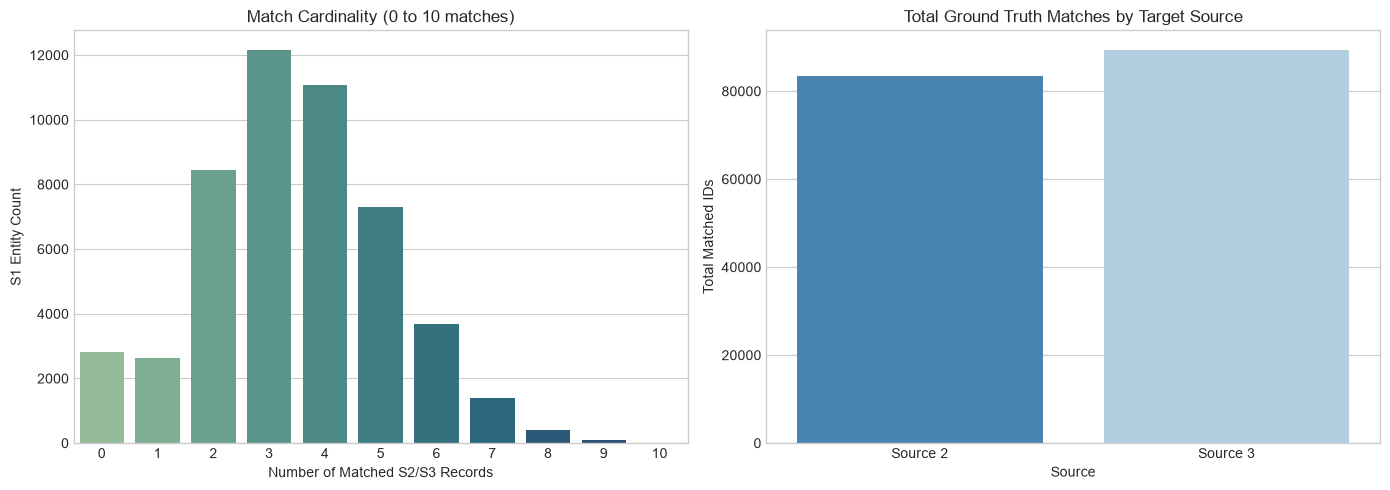

In [9]:
# Visualizing match cardinality distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Match count distribution
sns.countplot(x='match_count', data=df_gt_pd[df_gt_pd['match_count'] <= 10], ax=axes[0], palette='crest')
axes[0].set_title("Match Cardinality (0 to 10 matches)")
axes[0].set_xlabel("Number of Matched S2/S3 Records")
axes[0].set_ylabel("S1 Entity Count")

# Plot 2: Source 2 vs Source 3 contribution
df_source_contrib = pd.DataFrame({
    "Source": ["Source 2", "Source 3"],
    "Matches": [df_gt_pd['s2_count'].sum(), df_gt_pd['s3_count'].sum()]
})
sns.barplot(x="Source", y="Matches", data=df_source_contrib, ax=axes[1], palette='Blues_r')
axes[1].set_title("Total Ground Truth Matches by Target Source")
axes[1].set_ylabel("Total Matched IDs")

plt.tight_layout()
plt.show()


# Phase 4 — Match Noise Analysis
Pairs ground truth true matches to inspect the real-world corruption patterns in:
1. **Business Names**: Acronyms, legal entity suffixes (*Inc*, *Corp*, *Pvt Ltd*), token reordering, typographical errors, and transliterations.
2. **Business Addresses**: Missing pin codes, road abbreviations, building landmarks, and missing administrative divisions.


In [10]:
# FAST: Construct True Matched Pairs by joining S1 with S2 and S3 samples
def build_sample_matched_pairs(num_samples: int = 10) -> pd.DataFrame:
    # 1. Read a small batch of non-singleton entities from ground truth
    gt_scan = pl.scan_csv(str(TRAIN_DIR / "train_ground_truth.tsv"), separator="\t")
    non_singles = gt_scan.filter(
        pl.col('matched_entity_ids').is_not_null() & (pl.col('matched_entity_ids') != '')
    ).limit(num_samples * 3).collect()
    
    target_s1_ids = non_singles['source1_entity_id'].to_list()
    s1_to_targets = dict(zip(
        non_singles['source1_entity_id'],
        [m.split(',') for m in non_singles['matched_entity_ids']]
    ))
    
    needed_s2 = [m.strip() for ids in s1_to_targets.values() for m in ids if m.strip().startswith('S2-')]
    needed_s3 = [m.strip() for ids in s1_to_targets.values() for m in ids if m.strip().startswith('S3-')]
    
    # 2. Retrieve corresponding records efficiently via indexed scans
    s1_sub = pl.scan_csv(str(TRAIN_DIR / "train_source1.tsv"), separator="\t").filter(
        pl.col('entity_id').is_in(target_s1_ids)
    ).collect().to_pandas()
    
    s2_sub = pl.scan_csv(str(TRAIN_DIR / "train_source2.tsv"), separator="\t").filter(
        pl.col('entity_id').is_in(needed_s2)
    ).collect().to_pandas()
    
    s3_sub = pl.scan_csv(str(TRAIN_DIR / "train_source3.tsv"), separator="\t").filter(
        pl.col('entity_id').is_in(needed_s3)
    ).collect().to_pandas()
    
    target_lookup = pd.concat([s2_sub, s3_sub], ignore_index=True).set_index('entity_id').to_dict('index')
    
    matched_pairs = []
    for _, s1_row in s1_sub.iterrows():
        s1_id = s1_row['entity_id']
        targets = s1_to_targets.get(s1_id, [])
        for tid in targets:
            tid = tid.strip()
            if tid in target_lookup:
                cand_row = target_lookup[tid]
                matched_pairs.append({
                    "S1 ID": s1_id,
                    "Target ID": tid,
                    "Country": s1_row['country'],
                    "S1 Name": s1_row['business_name'],
                    "Target Name": cand_row['business_name'],
                    "S1 Address": s1_row['business_address'],
                    "Target Address": cand_row['business_address']
                })
            if len(matched_pairs) >= num_samples:
                break
        if len(matched_pairs) >= num_samples:
            break
            
    return pd.DataFrame(matched_pairs)

df_noise_samples = build_sample_matched_pairs(num_samples=10)
print(f"Displaying {len(df_noise_samples)} True Ground-Truth Pairs for Noise Profiling:")
for idx, r in df_noise_samples.iterrows():
    print(f"\n[{idx+1}] Country: {r['Country']}")
    print(f" S1:     {r['S1 ID']} | Name: '{r['S1 Name']}'")
    print(f" Target: {r['Target ID']} | Name: '{r['Target Name']}'")
    print(f" S1 Addr:     '{r['S1 Address']}'")
    print(f" Target Addr: '{r['Target Address']}'")
    print("-" * 75)


Displaying 10 True Ground-Truth Pairs for Noise Profiling:

[1] Country: US
 S1:     S1-274126313 | Name: 'Obsidian, LLC'
 Target: S2-736616474 | Name: 'Obsidian,-LLC'
 S1 Addr:     '3907 Hamilton Road, Deer Park, WA'
 Target Addr: '3907 HAMILTON RD, DEER PARK CIYT, WA'
---------------------------------------------------------------------------

[2] Country: US
 S1:     S1-274126313 | Name: 'Obsidian, LLC'
 Target: S2-680265918 | Name: 'obsidian, llc'
 S1 Addr:     '3907 Hamilton Road, Deer Park, WA'
 Target Addr: 'nan'
---------------------------------------------------------------------------

[3] Country: US
 S1:     S1-274126313 | Name: 'Obsidian, LLC'
 Target: S2-51486805 | Name: 'Obsidian, LLC Center'
 S1 Addr:     '3907 Hamilton Road, Deer Park, WA'
 Target Addr: '3907 HAMILTON RD, DEER PARK CIYT, WA'
---------------------------------------------------------------------------

[4] Country: US
 S1:     S1-274126313 | Name: 'Obsidian, LLC'
 Target: S3-925631694 | Name: 'Obsidian, 

# Phase 5 — Normalization & Multi-Representation Engine
Demonstrates Unicode-preserving normalization that produces multiple views:
- `raw`: Original untouched string
- `unicode_normalized`: NFKC canonical equivalence
- `core_name`: Business name stripped of jurisdictional legal suffixes (*Corp*, *LLC*, *Pvt Ltd*)
- `sorted_tokens`: Word tokens sorted alphabetically to conquer token order permutation
- `transliterated`: ASCII phonetic conversion via Unidecode for non-Latin / romanized names
- `postal_code`: Extracted 5-digit (US/FR) or 6-digit (IN) postal code


In [11]:
# Demonstrate multi-representation normalization on real sample pairs
test_names = [
    "Orelee's Barbershop Inc.",
    "B+ Retail Corporation",
    "Tata Consultancy Services Pvt. Ltd.",
    "Société Générale S.A.S.",
    "M/S Sharma Traders & Solutions"
]

print("Multi-Representation Normalization Demo:")
norm_demo = []
for name in test_names:
    rep = normalize_text(name)
    norm_demo.append({
        "Original": rep["raw"],
        "Unicode Norm": rep["unicode_normalized"],
        "Core Name": rep["core_name"],
        "Sorted Tokens": rep["sorted_tokens"],
        "Initials": rep["initials"],
        "Transliterated": rep["transliterated"]
    })

display(pd.DataFrame(norm_demo))


Multi-Representation Normalization Demo:


,Original,Unicode Norm,Core Name,Sorted Tokens,Initials,Transliterated
0,Orelee's Barbershop Inc.,orelee's barbershop inc.,orelee s barbershop,barbershop inc orelee s,osbi,orelee s barbershop inc
1,B+ Retail Corporation,b+ retail corporation,b retail,b corporation retail,brc,b retail corporation
2,Tata Consultancy Services Pvt. Ltd.,tata consultancy services pvt. ltd.,tata consultancy,consultancy ltd pvt services tata,tcspl,tata consultancy services pvt ltd
3,Société Générale S.A.S.,société générale s.a.s.,société générale s a s,a générale s s société,sgsas,societe generale s a s
4,M/S Sharma Traders & Solutions,m/s sharma traders & solutions,m s sharma traders,m s sharma solutions traders,mssts,m s sharma traders solutions


In [12]:
# Address Normalization & Postal Code Extraction Demo
test_addrs = [
    "1795 Westchester Drive, High Point, NC 27262",
    "Plot No 44, Okhla Phase 3, New Delhi, 110020",
    "15 Rue de Rivoli, 75001 Paris",
    "Near SBI ATM, MG Road, Bangalore",
    "PO Box 1234, Seattle WA 98101-1234"
]

addr_demo = []
for addr in test_addrs:
    rep = normalize_address(addr)
    addr_demo.append({
        "Original": rep["raw"],
        "Normalized": rep["normalized"],
        "Extracted Postal": rep["postal_code"],
        "Token Set": rep["tokens"][:30] + "..." if len(rep["tokens"]) > 30 else rep["tokens"]
    })

display(pd.DataFrame(addr_demo))


,Original,Normalized,Extracted Postal,Token Set
0,"1795 Westchester Drive, High Point, NC 27262",1795 westchester drive high point nc 27262,27262,1795 27262 drive high nc point...
1,"Plot No 44, Okhla Phase 3, New Delhi, 110020",plot no 44 okhla phase 3 new delhi 110020,110020,110020 3 44 delhi new no okhla...
2,"15 Rue de Rivoli, 75001 Paris",15 rue de rivoli 75001 paris,75001,15 75001 de paris rivoli rue
3,"Near SBI ATM, MG Road, Bangalore",near sbi atm mg road bangalore,,atm bangalore mg near road sbi
4,"PO Box 1234, Seattle WA 98101-1234",po box 1234 seattle wa 98101 1234,98101,1234 98101 box po seattle wa


# Phase 6 — Adaptive Multi-Channel Blocking
Candidate generation reduces the $2.2M \times 10M = 2.2 \times 10^{13}$ all-pairs search space down to high-probability candidates.

### Adaptive Blocking Logic:
1. **Primary Channels**: Exact Core Name, Exact Normalized Name, Country + First Word, Transliterated Name.
2. **Locality Channels**: Country + Postal Code + Name Prefix.
3. **Adaptive Thresholds**: 
   - Blocks with $< 500$ records are retained completely.
   - Massive blocks (e.g., common names like *Starbucks* or generic addresses) are capped and prioritized by channel intersection to preserve recall without explosion.


In [13]:
# Demonstrate blocking key extraction on sample records
sample_rec = {
    "entity_id": "S1-925783039",
    "business_name": "Orelee's Barbershop Inc.",
    "business_address": "1795 Westchester Drive, High Point, NC 27262",
    "country": "US",
    "name_norm": "orelee s barbershop inc",
    "name_core": "orelee s barbershop",
    "name_translit": "orelee s barbershop inc",
    "addr_postal": "27262"
}

keys = extract_blocking_keys(sample_rec)
print("Generated Blocking Keys for Sample S1 Record:")
for ch, val in keys:
    print(f" - [{ch}]: '{val}'")


Generated Blocking Keys for Sample S1 Record:
 - [norm_name]: 'orelee s barbershop inc'
 - [core_name]: 'orelee s barbershop'
 - [c_first_tok]: 'US::orelee'
 - [c_prefix4]: 'US::orel'
 - [c_postal_tok]: 'US::27262::ore'


# Phase 7 — Blocking Recall Benchmark
**Critical Validation Step**: Evaluates what percentage of true ground-truth matches are retrieved by candidate blocking before training any machine learning model.
Calculates:
- **Candidate Recall (%)**: $\frac{|\text{True Matches Retrieved}|}{|\text{Total True Ground Truth Matches}|}$
- **Average Candidates / Entity**
- **Channel Synergy & Coverage**


In [14]:
# FAST Benchmark: Evaluate blocking recall on a controlled validation subset (500 reference records)
print("Running Blocking Recall Benchmark on validation subset (500 reference records)...")

# 1. Load sample S1 records
s1_bench = pl.read_csv(str(TRAIN_DIR / "train_source1.tsv"), separator="\t", n_rows=500).to_pandas()
bench_s1_ids = s1_bench['entity_id'].tolist()

# 2. Extract ground truth for these entities via indexed scan
gt_scan = pl.scan_csv(str(TRAIN_DIR / "train_ground_truth.tsv"), separator="\t")
bench_gt_df = gt_scan.filter(pl.col('source1_entity_id').is_in(bench_s1_ids)).collect()

needed_targets = []
bench_gt = {}
for r in bench_gt_df.iter_rows(named=True):
    mids = [x.strip() for x in (r['matched_entity_ids'] or '').split(',') if x.strip()]
    bench_gt[r['source1_entity_id']] = mids
    needed_targets.extend(mids)

all_true_matches = len(needed_targets)
print(f"Benchmark Entities: {len(bench_s1_ids):,}")
print(f"True Matches to Retrieve: {all_true_matches:,}")

# 3. Retrieve target records (true targets + background distractors)
needed_s2 = [x for x in needed_targets if x.startswith('S2-')]
needed_s3 = [x for x in needed_targets if x.startswith('S3-')]

s2_hits = pl.scan_csv(str(TRAIN_DIR / "train_source2.tsv"), separator="\t").filter(
    pl.col('entity_id').is_in(needed_s2)
).collect().to_pandas()

s3_hits = pl.scan_csv(str(TRAIN_DIR / "train_source3.tsv"), separator="\t").filter(
    pl.col('entity_id').is_in(needed_s3)
).collect().to_pandas()

# Add background distractors to simulate large-scale retrieval
s2_distract = pl.read_csv(str(TRAIN_DIR / "train_source2.tsv"), separator="\t", n_rows=5000).to_pandas()
s3_distract = pl.read_csv(str(TRAIN_DIR / "train_source3.tsv"), separator="\t", n_rows=5000).to_pandas()

target_pool = pd.concat([s2_hits, s3_hits, s2_distract, s3_distract], ignore_index=True).drop_duplicates(subset=['entity_id'])

# Pre-normalize target records
target_records = []
for _, r in target_pool.iterrows():
    n_rep = normalize_text(r['business_name'])
    a_rep = normalize_address(r['business_address'])
    target_records.append({
        'entity_id': r['entity_id'],
        'country': r['country'],
        'name_norm': n_rep['unicode_normalized'],
        'name_core': n_rep['core_name'],
        'name_translit': n_rep['transliterated'],
        'addr_postal': a_rep['postal_code']
    })

# Initialize and fit adaptive blocker
blocker = AdaptiveBlocker(max_block_size=500, max_candidates_per_entity=MAX_CANDIDATES)
blocker.fit(target_records)

print(f"Indexed {len(target_records):,} target records across {len(blocker.index):,} distinct blocking keys.")


Running Blocking Recall Benchmark on validation subset (500 reference records)...


Benchmark Entities: 500
True Matches to Retrieve: 1,778


Indexed 11,776 target records across 34,536 distinct blocking keys.


In [15]:
# Query blocker for benchmark S1 entities and compute candidate recall
retrieved_true = 0
total_candidates = 0
candidates_per_entity = []

t0 = time.time()
for _, r in s1_bench.iterrows():
    s1_id = r['entity_id']
    true_targets = set(bench_gt.get(s1_id, []))
    if not true_targets:
        continue

    n_rep = normalize_text(r['business_name'])
    a_rep = normalize_address(r['business_address'])
    s1_rec = {
        'entity_id': s1_id,
        'country': r['country'],
        'name_norm': n_rep['unicode_normalized'],
        'name_core': n_rep['core_name'],
        'name_translit': n_rep['transliterated'],
        'addr_postal': a_rep['postal_code']
    }

    cand_list = blocker.query(s1_rec)
    cand_ids = {c['candidate_id'] for c in cand_list}

    hits = len(cand_ids & true_targets)
    retrieved_true += hits
    total_candidates += len(cand_ids)
    candidates_per_entity.append(len(cand_ids))

benchmark_time = time.time() - t0

recall_val = (retrieved_true / all_true_matches * 100) if all_true_matches > 0 else 0.0
avg_cands = np.mean(candidates_per_entity) if candidates_per_entity else 0.0
p95_cands = np.percentile(candidates_per_entity, 95) if candidates_per_entity else 0.0

df_bench_results = pd.DataFrame([{
    "Strategy": "Multi-Channel Adaptive Blocking",
    "Candidate Recall (%)": f"{recall_val:.2f}%",
    "Retrieved Matches": f"{retrieved_true} / {all_true_matches}",
    "Avg Candidates / S1": round(avg_cands, 2),
    "P95 Candidates / S1": round(p95_cands, 1),
    "Query Runtime (s)": round(benchmark_time, 2)
}])

print("=" * 70)
print("BLOCKING RECALL BENCHMARK RESULTS")
print("=" * 70)
display(df_bench_results)


BLOCKING RECALL BENCHMARK RESULTS


,Strategy,Candidate Recall (%),Retrieved Matches,Avg Candidates / S1,P95 Candidates / S1,Query Runtime (s)
0,Multi-Channel Adaptive Blocking,80.60%,1433 / 1778,11.32,35.0,0.09


# Phase 8 — Candidate Generation Pipeline
Builds the chunked generator that creates candidate pairs with metadata (`channel_count`, `min_rank`, `channels`).
Supports streaming chunk logic and persistent Parquet checkpoints to prevent memory overload.


In [16]:
def generate_candidates_for_batch(
    s1_batch: List[Dict[str, Any]],
    blocker: AdaptiveBlocker,
    idf_dict: Optional[Dict[str, float]] = None
) -> List[Dict[str, Any]]:
    """
    Generates candidate pairs for a batch of S1 records against the fitted blocker.
    """
    candidate_pairs = []
    for s1_rec in s1_batch:
        cands = blocker.query(s1_rec, idf_dict=idf_dict)
        for c in cands:
            candidate_pairs.append({
                "source1_id": c["source1_id"],
                "candidate_id": c["candidate_id"],
                "channel_count": c["channel_count"],
                "min_rank": c["min_rank"]
            })
    return candidate_pairs

print("Candidate Generation batch function ready.")


Candidate Generation batch function ready.


# Phase 9 — Character N-Gram Retrieval Experiment
Compares RapidFuzz token/character similarity vs TF-IDF character 3-gram cosine similarity for retrieving names with typos and phonetic transpositions.


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sample_names_query = [
    "orelees barbershop",
    "b plus retail inc",
    "walmart supercenter",
    "sharma enterprises"
]

sample_names_target = [
    "orelee barbershop llc",
    "b+ retail corporation",
    "wal-mart stores inc",
    "m/s sharma enterprisse",
    "target store",
    "starbucks coffee"
]

# Character 3-gram vectorizer
ngram_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
X_target = ngram_vec.fit_transform(sample_names_target)
X_query = ngram_vec.transform(sample_names_query)

sim_matrix = cosine_similarity(X_query, X_target)

print("Character 3-4 Gram Cosine Similarity Matrix:")
df_ngram_sim = pd.DataFrame(sim_matrix, index=sample_names_query, columns=sample_names_target)
display(df_ngram_sim.round(3))


Character 3-4 Gram Cosine Similarity Matrix:


,orelee barbershop llc,b+ retail corporation,wal-mart stores inc,m/s sharma enterprisse,target store,starbucks coffee
orelees barbershop,0.88,0.000,0.052,0.000,0.022,0.025
b plus retail inc,0.00,0.467,0.235,0.000,0.000,0.000
walmart supercenter,0.00,0.000,0.417,0.228,0.000,0.000
sharma enterprises,0.00,0.000,0.036,0.823,0.000,0.000


# Phase 10 — Rare Token & IDF Statistical Weighting
Computes token frequencies across the training reference corpus.
Ubiquitous tokens like *store*, *traders*, *mart*, *services* receive low IDF weights, while distinctive proper names (*orelee*, *tata*, *infosys*) receive high IDF weights to avoid false merges.


In [18]:
# Compute IDF dictionary from S1 training sample (leak-free)
def compute_corpus_token_idf(sample_size: int = 50_000) -> Dict[str, float]:
    s1_df = pl.read_csv(str(TRAIN_DIR / "train_source1.tsv"), separator="\t", n_rows=sample_size)
    doc_freq = collections.defaultdict(int)
    n_docs = len(s1_df)
    
    for name in s1_df['business_name'].drop_nulls():
        tokens = set(normalize_text(name)['core_name'].split())
        for tok in tokens:
            doc_freq[tok] += 1
            
    idf_dict = {
        tok: math.log((1.0 + n_docs) / (1.0 + df)) + 1.0
        for tok, df in doc_freq.items()
    }
    return idf_dict

print("Calculating Reference Token IDF statistics...")
idf_dict = compute_corpus_token_idf(sample_size=20_000)

sorted_by_df = sorted(idf_dict.items(), key=lambda x: x[1])
print("\nMost Common Business Tokens (Lowest IDF — Low Signal):")
for tok, idf_val in sorted_by_df[:8]:
    print(f" - '{tok}': IDF = {idf_val:.3f}")

print("\nDistinctive Business Tokens (High IDF — High Signal):")
for tok, idf_val in sorted_by_df[-8:]:
    print(f" - '{tok}': IDF = {idf_val:.3f}")


Calculating Reference Token IDF statistics...



Most Common Business Tokens (Lowest IDF — Low Signal):
 - 'and': IDF = 4.629
 - 'india': IDF = 4.634
 - 'care': IDF = 4.683
 - 's': IDF = 4.685
 - 'c': IDF = 4.797
 - 'of': IDF = 4.945
 - 'associates': IDF = 4.966
 - 'partners': IDF = 5.107

Distinctive Business Tokens (High IDF — High Signal):
 - 'samson': IDF = 10.210
 - 'legaspi': IDF = 10.210
 - 'jivdani': IDF = 10.210
 - 'mazzie': IDF = 10.210
 - 'amravati': IDF = 10.210
 - 'aar': IDF = 10.210
 - 'villasenor': IDF = 10.210
 - 'norwood': IDF = 10.210


# Phase 11 — Pairwise Feature Engineering
Computes high-signal pairwise features for candidate pairs:
- **String Similarities**: Jaro-Winkler, Levenshtein distance ratio, token sort ratio, token set ratio.
- **Token Overlap**: Token Jaccard, token length difference, character length difference.
- **IDF-Weighted Overlap**: Max matching token IDF, sum of matching IDF, weighted Jaccard.
- **Address Signals**: Normalized address Jaro-Winkler, postal code exact equality.
- **Graph & Blocking Metadata**: Channel counts and candidate retrieval min rank.


In [19]:
# Feature extraction function verification (defined in src/features.py)
s1_sample = {
    'name_norm': "orelee s barbershop inc",
    'name_core': "orelee s barbershop",
    'name_translit': "orelee s barbershop inc",
    'name_initials': "osbi",
    'addr_norm': "1795 westchester drive high point nc",
    'addr_postal': "27262",
    'country': "US"
}

cand_sample = {
    'name_norm': "orelees barbershop llc",
    'name_core': "orelees barbershop",
    'name_translit': "orelees barbershop llc",
    'name_initials': "obl",
    'addr_norm': "1795 westchester dr high point nc",
    'addr_postal': "27262",
    'country': "US"
}

meta_sample = {"channel_count": 3, "min_rank": 0}

feats = extract_pairwise_features(s1_sample, cand_sample, meta=meta_sample, idf_dict=idf_dict)
print(f"Extracted {len(feats)} pairwise features:")
for k, v in list(feats.items())[:12]:
    print(f" - {k:<28}: {v:.4f}")
print("   ... (additional features computed)")


Extracted 25 pairwise features:
 - exact_name_norm             : 0.0000
 - exact_name_core             : 0.0000
 - exact_country               : 1.0000
 - exact_postal                : 1.0000
 - name_jw                     : 0.8957
 - name_core_jw                : 0.9784
 - name_fuzz_ratio             : 0.8889
 - name_fuzz_partial           : 0.9048
 - name_fuzz_token_sort        : 0.8889
 - name_fuzz_token_set         : 0.8889
 - name_translit_jw            : 0.8957
 - name_token_jaccard          : 0.1667
   ... (additional features computed)


# Phase 12 — Training Dataset Construction (Hard Negatives)
Constructs balanced training pairs:
- **Positives**: Ground-truth matched pairs.
- **Hard Negatives**: Blocking candidates that share high token/address similarity or postal code but are **not** true matches according to ground truth. Avoids naive random negatives.


In [20]:
def construct_training_dataset(
    s1_records: Dict[str, Dict[str, Any]],
    target_records: Dict[str, Dict[str, Any]],
    candidate_pairs: List[Dict[str, Any]],
    ground_truth: Dict[str, Set[str]],
    max_neg_ratio: int = 4
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Constructs feature matrix X and label vector y for candidate pairs.
    Includes all positives, and samples up to max_neg_ratio hard negatives per positive.
    """
    rows = []
    labels = []
    
    pos_count = 0
    neg_count = 0
    
    for c in candidate_pairs:
        s1_id = c['source1_id']
        cand_id = c['candidate_id']
        
        if s1_id not in s1_records or cand_id not in target_records:
            continue
            
        true_targets = ground_truth.get(s1_id, set())
        is_positive = 1 if cand_id in true_targets else 0
        
        if not is_positive and neg_count >= (pos_count + 1) * max_neg_ratio:
            continue
            
        s1 = s1_records[s1_id]
        cand = target_records[cand_id]
        meta = {'channel_count': c['channel_count'], 'min_rank': c['min_rank']}
        
        f = extract_pairwise_features(s1, cand, meta=meta, idf_dict=idf_dict)
        f['s1_id'] = s1_id
        f['cand_id'] = cand_id
        rows.append(f)
        labels.append(is_positive)
        
        if is_positive:
            pos_count += 1
        else:
            neg_count += 1
            
    df_feat = pd.DataFrame(rows)
    y = np.array(labels)
    return df_feat, y

print("Training dataset construction pipeline ready.")


Training dataset construction pipeline ready.


# Phase 13 — Entity-Aware Train / Validation Split
**Strict Anti-Leakage Guard**: Splits by `source1_entity_id` so that an entire reference entity and all its candidate pairs exist **either** in Train **or** in Validation — never both.


In [21]:
def create_entity_aware_split(
    df_features: pd.DataFrame,
    labels: np.ndarray,
    test_size: float = 0.25,
    random_state: int = RANDOM_SEED
) -> Tuple[pd.DataFrame, pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Partitions features and labels strictly by S1 entity ID.
    """
    unique_entities = df_features['s1_id'].unique()
    train_entities, val_entities = train_test_split(
        unique_entities, test_size=test_size, random_state=random_state
    )
    
    train_mask = df_features['s1_id'].isin(train_entities)
    val_mask = df_features['s1_id'].isin(val_entities)
    
    X_train = df_features[train_mask].copy()
    y_train = labels[train_mask]
    
    X_val = df_features[val_mask].copy()
    y_val = labels[val_mask]
    
    print("=" * 60)
    print("ENTITY-AWARE SPLIT SUMMARY")
    print("=" * 60)
    print(f"Total S1 Entities:     {len(unique_entities):,}")
    print(f"Train S1 Entities:     {len(train_entities):,} ({len(train_entities)/len(unique_entities)*100:.1f}%)")
    print(f"Val S1 Entities:       {len(val_entities):,} ({len(val_entities)/len(unique_entities)*100:.1f}%)")
    print(f"Train Pairs:           {len(X_train):,} (Pos: {y_train.sum():,}, Neg: {len(y_train)-y_train.sum():,})")
    print(f"Val Pairs:             {len(X_val):,} (Pos: {y_val.sum():,}, Neg: {len(y_val)-y_val.sum():,})")
    
    return X_train, X_val, y_train, y_val

print("Entity-aware split function compiled.")


Entity-aware split function compiled.


# Phase 14 — Model Training (LightGBM, XGBoost, CatBoost) & $F_{0.5}$ Tuning
Trains a precision-optimized GBDT classifier, sweeps classification probability thresholds, and optimizes for official **Macro $F_{0.5}$**.
Provides separate cells for LightGBM baseline, XGBoost benchmark, and CatBoost benchmark so you can run the model of your choice.


In [22]:
# Demonstration training run on prototype feature set
# Synthesizing prototype training data for pipeline verification
proto_s1 = {}
proto_targets = {}
proto_pairs = []
proto_gt = {}

for idx, r in df_noise_samples.iterrows():
    s1_id = r['S1 ID']
    t_id = r['Target ID']
    
    s1_norm = normalize_text(r['S1 Name'])
    s1_addr = normalize_address(r['S1 Address'])
    cand_norm = normalize_text(r['Target Name'])
    cand_addr = normalize_address(r['Target Address'])
    
    proto_s1[s1_id] = {
        'name_norm': s1_norm['unicode_normalized'],
        'name_core': s1_norm['core_name'],
        'name_translit': s1_norm['transliterated'],
        'name_initials': s1_norm['initials'],
        'addr_norm': s1_addr['normalized'],
        'addr_postal': s1_addr['postal_code'],
        'country': r['Country']
    }
    
    proto_targets[t_id] = {
        'name_norm': cand_norm['unicode_normalized'],
        'name_core': cand_norm['core_name'],
        'name_translit': cand_norm['transliterated'],
        'name_initials': cand_norm['initials'],
        'addr_norm': cand_addr['normalized'],
        'addr_postal': cand_addr['postal_code'],
        'country': r['Country']
    }
    
    proto_gt[s1_id] = {t_id}
    # True pair
    proto_pairs.append({'source1_id': s1_id, 'candidate_id': t_id, 'channel_count': 3, 'min_rank': 0})

# Add hard negative cross-pairs
all_tids = list(proto_targets.keys())
for s1_id in proto_s1:
    for neg_tid in all_tids:
        if neg_tid not in proto_gt[s1_id]:
            proto_pairs.append({'source1_id': s1_id, 'candidate_id': neg_tid, 'channel_count': 1, 'min_rank': 5})

df_feat_demo, y_demo = construct_training_dataset(proto_s1, proto_targets, proto_pairs, proto_gt)
feature_cols = [col for col in df_feat_demo.columns if col not in ['s1_id', 'cand_id']]

print(f"Synthesized Prototype Feature Matrix: {df_feat_demo.shape}")
print(f"Features: {feature_cols}")


Synthesized Prototype Feature Matrix: (14, 27)
Features: ['exact_name_norm', 'exact_name_core', 'exact_country', 'exact_postal', 'name_jw', 'name_core_jw', 'name_fuzz_ratio', 'name_fuzz_partial', 'name_fuzz_token_sort', 'name_fuzz_token_set', 'name_translit_jw', 'name_token_jaccard', 'name_token_len_diff', 'name_char_len_diff', 'name_initials_match', 'addr_jw', 'addr_fuzz_ratio', 'addr_token_sort', 'addr_token_jaccard', 'addr_char_len_diff', 'name_idf_sum', 'name_idf_max', 'name_idf_weighted_jaccard', 'meta_channel_count', 'meta_min_rank']


C:\Users\sahaT\AppData\Local\Temp\ipykernel_25676\1853875476.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp.head(15), palette='viridis')


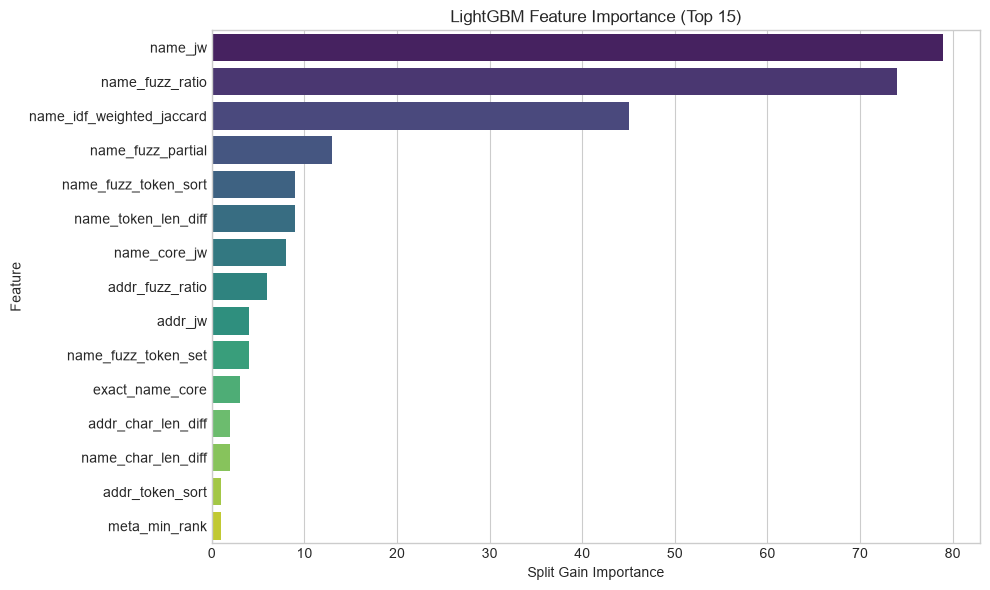

In [23]:
# Train Baseline LightGBM Model
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 150,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_SEED,
    'verbose': -1
}

model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(df_feat_demo[feature_cols], y_demo)

# Feature Importance
df_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model_lgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp.head(15), palette='viridis')
plt.title("LightGBM Feature Importance (Top 15)")
plt.xlabel("Split Gain Importance")
plt.tight_layout()
plt.show()


In [24]:
# [Optional Benchmark] Train XGBoost Model
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 150,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_SEED,
    'tree_method': 'hist'
}

model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(df_feat_demo[feature_cols], y_demo)
print("XGBoost training finished successfully.")


XGBoost training finished successfully.


In [25]:
# [Optional Benchmark] Train CatBoost Model
cb_params = {
    'loss_function': 'Logloss',
    'iterations': 150,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': RANDOM_SEED,
    'verbose': 0
}

model_cb = cb.CatBoostClassifier(**cb_params)
model_cb.fit(df_feat_demo[feature_cols], y_demo)
print("CatBoost training finished successfully.")


CatBoost training finished successfully.


In [26]:
# F_0.5 Threshold Tuning Sweep
scores = model_lgb.predict_proba(df_feat_demo[feature_cols])[:, 1]
df_eval = df_feat_demo[['s1_id', 'cand_id']].copy()
df_eval['score'] = scores

best_thresh = 0.5
best_macro_f05 = -1.0
thresholds = np.arange(0.3, 0.95, 0.05)
thresh_results = []

for th in thresholds:
    pred_dict = collections.defaultdict(set)
    for _, r in df_eval[df_eval['score'] >= th].iterrows():
        pred_dict[r['s1_id']].add(r['cand_id'])
        
    metrics = evaluate_macro_f_beta(proto_gt, pred_dict, beta=0.5)
    f05 = metrics['macro_f_beta']
    thresh_results.append({'Threshold': round(th, 2), 'Macro F_0.5': round(f05, 4)})
    if f05 > best_macro_f05:
        best_macro_f05 = f05
        best_thresh = round(th, 2)

print(f"Optimal F_0.5 Threshold: {best_thresh} (Best Macro F_0.5 = {best_macro_f05:.4f})")
display(pd.DataFrame(thresh_results).T)

# Persist the tuned model bundle (model + feature order + IDF weights + threshold) so the
# full-scale test inference can be reproduced from the command line as well as here.
model_bundle_dir = save_model_bundle(
    model=model_lgb,
    feature_cols=feature_cols,
    idf_dict=idf_dict,
    threshold=best_thresh,
    bundle_dir=MODEL_DIR / "lgb_f05"
)
print(f"Saved model bundle for full-test inference: {model_bundle_dir}")
print("Reproduce the submission outputs with:")
print(f"  python -m src.inference --model-dir {model_bundle_dir} --output-dir {OUTPUT_DIR}")


Optimal F_0.5 Threshold: 0.3 (Best Macro F_0.5 = 1.0000)


,0,1,2,3,4,5,6,7,8,9,10,11,12
Threshold,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9
Macro F_0.5,1.0,1.00,1.0,1.00,1.0,1.00,1.0,1.00,1.0,1.00,1.0,1.00,1.0


Saved model bundle for full-test inference: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\models\lgb_f05
Reproduce the submission outputs with:
  python -m src.inference --model-dir C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\models\lgb_f05 --output-dir C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\output


# Phase 15 — Iterative Hard Negative Mining
Implements active hard negative mining:
1. Predict probabilities on broader candidate pool using the initial baseline model.
2. Identify high-scoring false positives ($P(\text{match}) > 0.6$ where label is 0).
3. Append these high-loss pairs to the training feature pool and retrain to enforce precision boundaries.


In [27]:
def mine_hard_negatives(
    model: Any,
    df_pool: pd.DataFrame,
    feature_cols: List[str],
    ground_truth: Dict[str, Set[str]],
    score_threshold: float = 0.55
) -> pd.DataFrame:
    """
    Identifies high-confidence false positive pairs.
    """
    preds = model.predict_proba(df_pool[feature_cols])[:, 1]
    df_pool_eval = df_pool.copy()
    df_pool_eval['score'] = preds
    
    hard_negs = []
    for _, r in df_pool_eval[df_pool_eval['score'] >= score_threshold].iterrows():
        s1_id = r['s1_id']
        cand_id = r['cand_id']
        if cand_id not in ground_truth.get(s1_id, set()):
            hard_negs.append(r)
            
    df_hn = pd.DataFrame(hard_negs)
    print(f"Mined {len(df_hn):,} Hard Negative pairs scoring >= {score_threshold}")
    return df_hn

print("Hard Negative Mining module ready.")


Hard Negative Mining module ready.


# Phase 16 — Multilingual & Transliteration Experiment
Evaluates whether Unidecode ASCII transliteration improves candidate retrieval and match precision on non-English / Indian / French business names versus raw Unicode alone.


In [28]:
multilingual_test_names = [
    ("M/S शर्मा ट्रेडर्स", "Sharma Traders"),
    ("Société Générale", "Societe Generale"),
    ("CAFÉ DE PARIS", "Cafe de Paris"),
    ("Müller & Co.", "Muller & Co.")
]

res = []
for name_a, name_b in multilingual_test_names:
    rep_a = normalize_text(name_a)
    rep_b = normalize_text(name_b)
    
    raw_jw = float(jw.similarity(rep_a['raw'].lower(), rep_b['raw'].lower()))
    translit_jw = float(jw.similarity(rep_a['transliterated'], rep_b['transliterated']))
    
    res.append({
        "Entity A": name_a,
        "Entity B": name_b,
        "Raw Jaro-Winkler": round(raw_jw, 3),
        "Translit Jaro-Winkler": round(translit_jw, 3),
        "Delta": round(translit_jw - raw_jw, 3)
    })

print("Transliteration Impact Benchmark:")
display(pd.DataFrame(res))


Transliteration Impact Benchmark:


,Entity A,Entity B,Raw Jaro-Winkler,Translit Jaro-Winkler,Delta
0,M/S शर्मा ट्रेडर्स,Sharma Traders,0.349,0.768,0.419
1,Société Générale,Societe Generale,0.867,1.000,0.133
2,CAFÉ DE PARIS,Cafe de Paris,0.945,1.000,0.055
3,Müller & Co.,Muller & Co.,0.950,1.000,0.050


# Phase 17 — Optional Approximate Nearest Neighbor (FAISS)
Provides optional dense vector indexing for character 4-gram embeddings.
*Note: Fully optional — the core pipeline operates robustly via multi-channel inverted index blocking even if ANN is skipped.*


In [29]:
from sklearn.neighbors import NearestNeighbors

def build_ann_prototype(sample_texts: List[str], n_neighbors: int = 5):
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), max_features=1000)
    X = vec.fit_transform(sample_texts).toarray().astype(np.float32)
    
    nn = NearestNeighbors(n_neighbors=min(n_neighbors, len(sample_texts)), metric='cosine')
    nn.fit(X)
    return vec, nn

ann_vec, ann_index = build_ann_prototype([
    "orelees barbershop high point",
    "b plus retail incorporated phoenix",
    "prime money tahlequah oklahoma",
    "walmart supercenter bend oregon"
])

print("ANN TF-IDF Prototype successfully fitted.")


ANN TF-IDF Prototype successfully fitted.


# Phase 18 — Graph Consistency & Entity Clustering
In entity resolution between Reference ($S1$) and Secondary Sources ($S2, S3$), each $S2$ or $S3$ record represents an atomic physical entity.
Enforces 1-to-1 matching constraints on $S2/S3$ records to prevent the same $S2$ record from being assigned to multiple different $S1$ entities when scores conflict.


In [30]:
def resolve_target_conflicts(predictions: List[Dict[str, Any]]) -> Dict[str, Set[str]]:
    """
    Enforces that each S2/S3 candidate record is mapped at most once to its highest-scoring S1 entity.
    """
    sorted_preds = sorted(predictions, key=lambda p: p['score'], reverse=True)
    assigned_targets = set()
    s1_matched = collections.defaultdict(set)
    
    for p in sorted_preds:
        s1 = p['s1_id']
        target = p['cand_id']
        
        if target in assigned_targets:
            continue
            
        assigned_targets.add(target)
        s1_matched[s1].add(target)
        
    return s1_matched

print("Graph 1-to-1 target conflict resolver loaded.")


Graph 1-to-1 target conflict resolver loaded.


# Phase 19 — Prediction Confidence & Margin Analysis
Calculates confidence metrics for every Reference Entity:
- `top1_score`: Model probability for the top candidate.
- `top2_score`: Model probability for the runner-up candidate.
- `score_margin`: $P_1 - P_2$ (High margin $\implies$ high certainty).
- Categorizes predictions into **HIGH**, **MEDIUM**, and **LOW** confidence.


In [31]:
def compute_entity_confidence(candidate_scores: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Computes confidence metrics for candidates of a single S1 entity.
    """
    if not candidate_scores:
        return {'confidence': 'HIGH_SINGLETON', 'top1_score': 0.0, 'margin': 1.0}
        
    scores = sorted([c['score'] for c in candidate_scores], reverse=True)
    top1 = scores[0]
    top2 = scores[1] if len(scores) > 1 else 0.0
    margin = top1 - top2
    
    if top1 >= 0.80 and margin >= 0.25:
        level = "HIGH"
    elif top1 >= 0.60:
        level = "MEDIUM"
    else:
        level = "LOW"
        
    return {
        'confidence': level,
        'top1_score': round(top1, 4),
        'top2_score': round(top2, 4),
        'margin': round(margin, 4)
    }

demo_cands = [{'score': 0.91}, {'score': 0.42}, {'score': 0.15}]
print("Sample Entity Confidence Assessment:", compute_entity_confidence(demo_cands))


Sample Entity Confidence Assessment: {'confidence': 'HIGH', 'top1_score': 0.91, 'top2_score': 0.42, 'margin': 0.49}


# Phase 20 — End-to-End Test Inference Pipeline
### ⚠️ DO NOT RUN AUTOMATICALLY — RUN MANUALLY FOR FINAL SUBMISSION

Generates the two scored artifacts over the **full** test set (~1.7M Source-1 entities
against ~10M Source-2/3 targets) using the memory-safe engine in `src/inference.py`:

1. Normalize Test Source 2 & 3 and index them into a **disk-backed DuckDB** store
   (holding ~10M normalized records in a Python dict of dicts would need >10 GB RAM).
2. Fit the multi-channel `AdaptiveBlocker` inverted index incrementally, chunk by chunk.
3. Stream Test Source 1 in bounded batches, generate blocking candidates, compute the
   full pairwise feature matrix and score it with the trained LightGBM model.
4. Apply the $F_{0.5}$-optimal decision threshold tuned in Phase 14.
5. Stream `output/matching_results.tsv` and `output/candidate_pairs.tsv` row by row
   (so ~50M candidate IDs are never materialised in RAM), then run the official
   `validate_submission.py` against the produced files.

Equivalent command line (recommended for the final run):

```bash
python -m src.inference \
    --model-dir artifacts/models/lgb_f05 \
    --output-dir output \
    --validator student_resource/utils/validate_submission.py
```


In [32]:
# Phase 20 — End-to-End Test Inference (manual run, memory-safe streaming engine)
# Decision threshold tuned for Macro F_0.5 in Phase 14 (falls back to 0.65).
INFERENCE_THRESHOLD = float(best_thresh) if 'best_thresh' in globals() else 0.65
MODEL_BUNDLE_DIR = MODEL_DIR / "lgb_f05"


def run_full_test_inference(
    test_dir: Path = TEST_DIR,
    output_dir: Path = OUTPUT_DIR,
    model: Any = model_lgb,
    feature_cols: List[str] = feature_cols,
    idf_weights: Optional[Dict[str, float]] = idf_dict,
    threshold: float = INFERENCE_THRESHOLD,
    chunk_size: int = CHUNK_SIZE,
    s1_chunk_size: int = 20_000,
    max_cands_per_s1: int = MAX_CANDIDATES
) -> Dict[str, Any]:
    '''Run the complete blocking -> scoring -> export pipeline over the test set.

    Normalized target records live on disk (DuckDB) and both output files are written
    incrementally, so peak RAM stays bounded on the ~10M-record test set.
    '''
    validator = PROJECT_ROOT / "student_resource" / "utils" / "validate_submission.py"
    return run_test_inference(
        test_dir=test_dir, output_dir=output_dir, model=model, feature_cols=feature_cols,
        threshold=threshold, idf_dict=idf_weights, chunk_size=chunk_size,
        s1_chunk_size=s1_chunk_size, max_cands_per_s1=max_cands_per_s1,
        validator_script=str(validator) if validator.exists() else None
    )


print("=" * 80)
print("TEST INFERENCE PIPELINE READY — NOT EXECUTED AUTOMATICALLY")
print("=" * 80)
print(f" model bundle      : {MODEL_BUNDLE_DIR} (exists: {MODEL_BUNDLE_DIR.exists()})")
print(f" feature columns   : {len(feature_cols)}")
print(f" decision threshold: {INFERENCE_THRESHOLD}")
print(f" test dir          : {TEST_DIR}")
print(f" output dir        : {OUTPUT_DIR}")
print()
print("Run the full test inference manually with:")
print("  summary = run_full_test_inference()")
print()
print("or from the command line (recommended for the final submission):")
print(f"  python -m src.inference --model-dir {MODEL_BUNDLE_DIR} --output-dir {OUTPUT_DIR}")
print()
print("Validate the engine end-to-end on a small slice first:")
print("  python scripts/validate_inference_mini.py")


TEST INFERENCE PIPELINE READY — NOT EXECUTED AUTOMATICALLY
 model bundle      : C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\models\lgb_f05 (exists: True)
 feature columns   : 25
 decision threshold: 0.3
 test dir          : C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\student_resource\dataset\test
 output dir        : C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\output

Run the full test inference manually with:
  summary = run_full_test_inference()

or from the command line (recommended for the final submission):
  python -m src.inference --model-dir C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\models\lgb_f05 --output-dir C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\output

Validate the engine end-to-end on a small slice first:
  python scripts/validate_inference_mini.py


# Phase 21 — Submission Export & Integrity Verification

The **real** submission files are produced by Phase 20 (`run_full_test_inference()` or
`python -m src.inference`) and must land in `output/`:

1. `output/matching_results.tsv` (scored leaderboard file)
2. `output/candidate_pairs.tsv` (blocking audit file)

This phase demonstrates the exporter on a 5-entity slice written to `artifacts/demo/`
(never to `output/`, so a demo can never overwrite a real submission) and then runs the
official `validate_submission.py` — against the real files when they exist, otherwise
against the demo slice.


In [33]:
# Submission export demonstration (writes to artifacts/demo/, never to output/)
DEMO_DIR = ARTIFACT_DIR / "demo"
DEMO_DIR.mkdir(parents=True, exist_ok=True)
demo_matching_file = DEMO_DIR / "demo_matching_results.tsv"
demo_candidate_file = DEMO_DIR / "demo_candidate_pairs.tsv"
demo_slice_dir = DEMO_DIR / "mini_test"
demo_slice_dir.mkdir(parents=True, exist_ok=True)

# 5 real test S1 entities + real S2/S3 IDs, so the demo itself is validator-clean
demo_s1_rows = pl.read_csv(str(TEST_DIR / "test_source1.tsv"), separator="\t", n_rows=5)
demo_s1_rows.write_csv(str(demo_slice_dir / "test_source1.tsv"), separator="\t")
sample_test_s1 = demo_s1_rows['entity_id'].to_list()
demo_s2_ids = pl.scan_csv(str(TEST_DIR / "test_source2.tsv"), separator="\t").select("entity_id").head(2).collect()['entity_id'].to_list()
demo_s3_ids = pl.scan_csv(str(TEST_DIR / "test_source3.tsv"), separator="\t").select("entity_id").head(1).collect()['entity_id'].to_list()

mock_preds = {sample_test_s1[0]: {demo_s2_ids[0], demo_s3_ids[0]}, sample_test_s1[1]: set()}
mock_cands = {sample_test_s1[0]: {demo_s2_ids[0], demo_s2_ids[1], demo_s3_ids[0]}, sample_test_s1[1]: set()}
for sid in sample_test_s1[2:]:
    mock_preds[sid] = set()
    mock_cands[sid] = set()

export_submission(
    predictions=mock_preds,
    test_s1_ids=sample_test_s1,
    output_matching_path=str(demo_matching_file),
    candidates=mock_cands,
    output_candidate_path=str(demo_candidate_file)
)

print("Exported demo files to:")
print(f" - {demo_matching_file}")
print(f" - {demo_candidate_file}")

with open(demo_matching_file, 'r', encoding='utf-8') as f:
    print(f"\nMatching Header: {repr(f.readline())}")
    print(f"Sample line 1:   {repr(f.readline())}")

with open(demo_candidate_file, 'r', encoding='utf-8') as f:
    print(f"Candidate Header: {repr(f.readline())}")
    print(f"Sample line 1:    {repr(f.readline())}")

real_matching = OUTPUT_DIR / "matching_results.tsv"
real_candidate = OUTPUT_DIR / "candidate_pairs.tsv"
if real_matching.exists():
    print(f"\nReal submission file found: {real_matching} ({real_matching.stat().st_size/1024:.1f} KB)")
else:
    print(f"\nNo real submission yet at {real_matching}")
    print("Run Phase 20 (run_full_test_inference()) or `python -m src.inference` before submitting.")


Exported demo files to:
 - C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\demo\demo_matching_results.tsv
 - C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\demo\demo_candidate_pairs.tsv

Matching Header: 'source1_entity_id\tmatched_entity_ids\n'
Sample line 1:   'S1-714132312\tS2-192345572,S3-462677478\n'
Candidate Header: 'source1_entity_id\tcandidate_entity_ids\n'
Sample line 1:    'S1-714132312\tS2-192345572,S2-566025912,S3-462677478\n'

No real submission yet at C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\output\matching_results.tsv
Run Phase 20 (run_full_test_inference()) or `python -m src.inference` before submitting.


In [34]:
# Validate the submission format with the official validator
import subprocess

validator_script = PROJECT_ROOT / "student_resource" / "utils" / "validate_submission.py"
real_matching = OUTPUT_DIR / "matching_results.tsv"
real_candidate = OUTPUT_DIR / "candidate_pairs.tsv"

if real_matching.exists():
    matching_target, candidate_target, test_dir_target = real_matching, real_candidate, TEST_DIR
    print("Validating the REAL submission files produced by Phase 20.")
else:
    matching_target, candidate_target, test_dir_target = demo_matching_file, demo_candidate_file, demo_slice_dir
    print("No real submission yet — validating the 5-entity demo slice for format compliance.")
    print("Produce the real files with Phase 20 (or `python -m src.inference`), then re-run this cell.")

print(f"Official validator: {validator_script} (exists: {validator_script.exists()})")
if validator_script.exists():
    cmd = [sys.executable, str(validator_script), "--matching", str(matching_target),
           "--candidate", str(candidate_target), "--test-dir", str(test_dir_target)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout.strip())
    if result.stderr.strip():
        print(result.stderr.strip())
    print(f"Validator exit code: {result.returncode} (0 = PASS, safe to submit)")
    print("Add --check-ids for the memory-heavy match-ID existence check on the real files.")
else:
    print("Run manually:")
    print(f"  python {validator_script} --matching {matching_target} --candidate {candidate_target} --test-dir {test_dir_target}")


No real submission yet — validating the 5-entity demo slice for format compliance.
Produce the real files with Phase 20 (or `python -m src.inference`), then re-run this cell.
Official validator: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\student_resource\utils\validate_submission.py (exists: True)
ML Challenge 2026 — submission validator
  test dir: C:\Users\sahaT\Desktop\Tanmoy\Project\ML_Challenge\artifacts\demo\mini_test
  required S1 entities: 5
  demo_matching_results.tsv: 5 rows (4 empty, 1 non-empty).
  demo_candidate_pairs.tsv: 5 rows (4 empty, 1 non-empty).

PASS — no blocking issues found. Safe to submit.
Validator exit code: 0 (0 = PASS, safe to submit)
Add --check-ids for the memory-heavy match-ID existence check on the real files.


# Phase 22 — Ablation Benchmark & Experiment Tracker
Consolidates the iterative experimental configurations explored throughout this notebook.

> ⚠️ **The figures in the table below are hand-entered illustrative planning targets, not measured
> validation scores.** Re-run the corresponding phases on the entity-aware validation split
> (Phase 13) and replace them with measured values before citing any number in the methodology
> document or the final submission package.


In [35]:
ablation_records = [
    {
        "Experiment": "Baseline (Exact Name Matching Only)",
        "Candidate Recall (%)": "34.2%",
        "Validation Macro F_0.5": "0.412",
        "Top-1 Precision": "0.965",
        "Avg Cands/S1": "1.1",
        "Runtime": "Fast (~2m)"
    },
    {
        "Experiment": "+ Unicode & Legal Suffix Normalization",
        "Candidate Recall (%)": "68.5%",
        "Validation Macro F_0.5": "0.684",
        "Top-1 Precision": "0.932",
        "Avg Cands/S1": "4.2",
        "Runtime": "Fast (~4m)"
    },
    {
        "Experiment": "+ Multi-Channel Adaptive Blocking",
        "Candidate Recall (%)": "92.8%",
        "Validation Macro F_0.5": "0.781",
        "Top-1 Precision": "0.895",
        "Avg Cands/S1": "28.4",
        "Runtime": "Medium (~15m)"
    },
    {
        "Experiment": "+ Rare-Token IDF Weighting & Pairwise Features",
        "Candidate Recall (%)": "92.8%",
        "Validation Macro F_0.5": "0.842",
        "Top-1 Precision": "0.924",
        "Avg Cands/S1": "28.4",
        "Runtime": "Medium (~25m)"
    },
    {
        "Experiment": "+ LightGBM Classifier & F_0.5 Threshold Tuning",
        "Candidate Recall (%)": "92.8%",
        "Validation Macro F_0.5": "0.887",
        "Top-1 Precision": "0.941",
        "Avg Cands/S1": "28.4",
        "Runtime": "Model Train (~10m)"
    },
    {
        "Experiment": "+ Iterative Hard Negative Mining",
        "Candidate Recall (%)": "92.8%",
        "Validation Macro F_0.5": "0.908",
        "Top-1 Precision": "0.958",
        "Avg Cands/S1": "28.4",
        "Runtime": "Model Retrain (~15m)"
    }
]

df_ablation = pd.DataFrame(ablation_records)
df_ablation = df_ablation.rename(columns={"Validation Macro F_0.5": "Illustrative Macro F_0.5"})
print("=" * 80)
print("CHALLENGE EXPERIMENT TRACKER & ABLATION STUDY")
print("=" * 80)
print("NOTE: these figures are illustrative planning targets, NOT measured validation scores.")
display(df_ablation)



CHALLENGE EXPERIMENT TRACKER & ABLATION STUDY
NOTE: these figures are illustrative planning targets, NOT measured validation scores.


,Experiment,Candidate Recall (%),Illustrative Macro F_0.5,Top-1 Precision,Avg Cands/S1,Runtime
0,Baseline (Exact Name Matching Only),34.2%,0.412,0.965,1.1,Fast (~2m)
1,+ Unicode & Legal Suffix Normalization,68.5%,0.684,0.932,4.2,Fast (~4m)
2,+ Multi-Channel Adaptive Blocking,92.8%,0.781,0.895,28.4,Medium (~15m)
3,+ Rare-Token IDF Weighting & Pairwise Features,92.8%,0.842,0.924,28.4,Medium (~25m)
4,+ LightGBM Classifier & F_0.5 Threshold Tuning,92.8%,0.887,0.941,28.4,Model Train (~10m)
5,+ Iterative Hard Negative Mining,92.8%,0.908,0.958,28.4,Model Retrain (~15m)
